Simulación Monte Carlo - Presupuesto con Incertidumbre
1.  Modelo determinístico de cálculo de costos

In [1]:
#paquetes a ser utilizados
import matplotlib.pyplot as plt
import random
import numpy as np
%matplotlib inline
import seaborn as sns

c:\Users\ego_2\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Costos base (valores medios de referencia)
costos_base = {
    "materiales": 300,
    "mano_obra": 500,
    "transporte": 100,
    "licencias": 80,
    "imprevistos": 120
}

# Suma determinística
presupuesto_deterministico = sum(costos_base.values())
print(f"Presupuesto determinístico: ${presupuesto_deterministico}")


Presupuesto determinístico: $1100


In [3]:
# Distribuciones normales alrededor de los valores base con un 10-20% de desviación estándar
def generar_costos():
    return {
        "materiales": np.random.normal(300, 30),
        "mano_obra": np.random.normal(500, 50),
        "transporte": np.random.normal(100, 15),
        "licencias": np.random.normal(80, 10),
        "imprevistos": np.random.normal(120, 25)
    }


In [4]:
resultados = []
num_iteraciones = 5000

for _ in range(num_iteraciones):
    costos_simulados = generar_costos()
    total = sum(costos_simulados.values())
    resultados.append(total)


In [5]:
resultados

[1117.3204149905089,
 1180.8312882215298,
 1073.871969577414,
 1144.8490226652707,
 1183.228427749473,
 1042.600795236726,
 983.8788506919298,
 1068.1481755247175,
 1053.1278582157229,
 1114.2348672288413,
 1114.806667982807,
 1012.9529174817206,
 1066.983536190058,
 1104.3312911933892,
 1276.1640676934376,
 1063.6747983721666,
 1118.6746764991303,
 1087.0381393114378,
 1152.626247618146,
 1010.3491729594654,
 1165.0275657107456,
 982.2019781269089,
 1098.8372410664742,
 1215.9303817000416,
 1102.804764899148,
 1079.0093040719119,
 1078.6831650387464,
 1123.2594285017765,
 1140.267447266772,
 1023.6274112663777,
 1161.6443619676575,
 1138.9513793383724,
 1171.6558260255856,
 1130.68657132738,
 1137.7137622933851,
 1168.4622450719091,
 1169.3893875710687,
 1075.4688664143994,
 1162.20640897034,
 1094.180248470621,
 1062.317968350807,
 1164.2575767407884,
 1197.0533198969554,
 1110.9921893450844,
 1073.8671022880171,
 1048.2818054395564,
 1082.117887597361,
 1040.143493341971,
 1208.5398

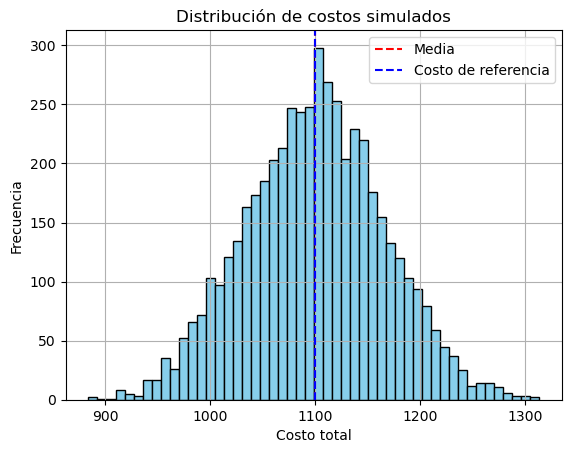

Media del presupuesto simulado: 1099.44
Desviación estándar: 66.09


In [6]:
plt.hist(resultados, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribución de costos simulados")
plt.xlabel("Costo total")
plt.ylabel("Frecuencia")
plt.grid(True)

plt.axvline(x=np.mean(resultados), color='r', linestyle='--', label='Media')
plt.axvline(x=presupuesto_deterministico, color='b', linestyle='--', label='Costo de referencia')
plt.legend()
plt.show()

print(f"Media del presupuesto simulado: {np.mean(resultados):.2f}")
print(f"Desviación estándar: {np.std(resultados):.2f}")


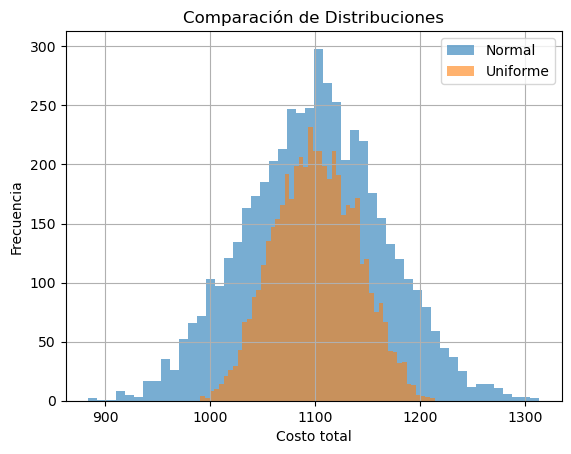

In [7]:
def generar_costos_uniforme():
    return {
        "materiales": np.random.uniform(270, 330),
        "mano_obra": np.random.uniform(450, 550),
        "transporte": np.random.uniform(90, 110),
        "licencias": np.random.uniform(70, 90),
        "imprevistos": np.random.uniform(90, 150)
    }

resultados_uniforme = [sum(generar_costos_uniforme().values()) for _ in range(num_iteraciones)]

# Comparación visual
plt.hist(resultados, bins=50, alpha=0.6, label='Normal')
plt.hist(resultados_uniforme, bins=50, alpha=0.6, label='Uniforme')
plt.title("Comparación de Distribuciones")
plt.xlabel("Costo total")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.show()


In [8]:
#numero de muestras
print('Numero de muestras: ',resultados.__len__())
total_muestras=resultados.__len__()

Numero de muestras:  5000


In [9]:
costo_ok=[x for x in resultados if x < presupuesto_deterministico]


In [10]:
#probabilidad de que sea un total menor al costo de referencia
num_costo_ok=costo_ok.__len__()
prob_costo_ref=num_costo_ok/total_muestras
print('Probabilidad de que el costo sea menor al costo de referencia: ' + f'{prob_costo_ref*100:.2f} %')

Probabilidad de que el costo sea menor al costo de referencia: 49.78 %


In [11]:
#percentiles
for i in range(0,100,5):
    print(f'{i} %: {np.percentile(resultados, i)}')

0 %: 884.0864338233362
5 %: 989.4641097782546
10 %: 1012.2529641664242
15 %: 1029.5600234002059
20 %: 1042.0623395873336
25 %: 1054.6766357933138
30 %: 1065.173068576031
35 %: 1075.2022845183847
40 %: 1083.3354168011988
45 %: 1092.7279095433682
50 %: 1100.3123038242927
55 %: 1107.91449007726
60 %: 1115.814185056451
65 %: 1124.1645322923066
70 %: 1134.5148703789205
75 %: 1144.2080798898173
80 %: 1154.5345893342949
85 %: 1168.2031299436492
90 %: 1185.2215125225753
95 %: 1208.1743364343276


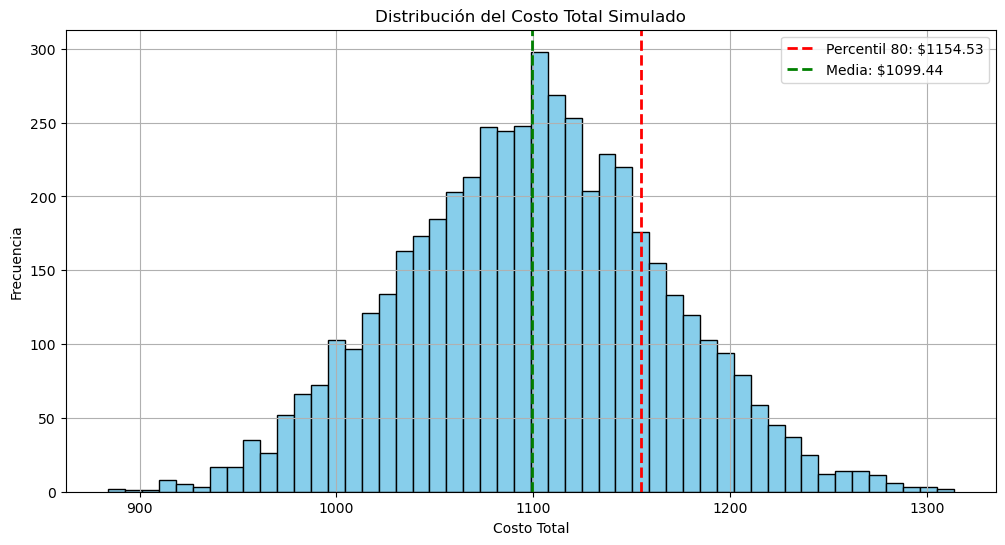

In [14]:
import matplotlib.pyplot as plt

# Histograma de resultados
plt.figure(figsize=(12,6))
plt.hist(resultados, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribución del Costo Total Simulado")
plt.xlabel("Costo Total")
plt.ylabel("Frecuencia")

# Línea vertical en el percentil 80 (ejemplo con presupuesto de 1150)
p80 = np.percentile(resultados, 80)
plt.axvline(p80, color='red', linestyle='--', linewidth=2, label=f'Percentil 80: ${p80:.2f}')

# Línea vertical en la media
media = np.mean(resultados)
plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media: ${media:.2f}')

plt.legend()
plt.grid(True)
plt.show()


Hay un 49.78% de probabilidad de que el costo total esté por debajo del costo de referencia.

¿Qué implica eso en términos prácticos?
Si tú estableces un presupuesto igual al costo de referencia, entonces solo en la mitad de los casos aproximadamente (49.78%) te mantendrás dentro del presupuesto.

En cambio, el otro ~50% de las veces el costo será mayor, lo que representa un riesgo de sobrecostos si no se toman medidas.



 Conclusiones Generales del Proyecto
1. La simulación Monte Carlo permite tomar decisiones informadas ante la incertidumbre
Modelaste un escenario de presupuesto con múltiples variables aleatorias.

Ejecutando 5,000 iteraciones para ver cómo varía el costo total.

Puede ver que el presupuesto no es un solo número, sino una distribución de posibles resultados.

2. El valor promedio del presupuesto simulado fue de aproximadamente $1100.92
Esto representa el costo "esperado", es decir, el valor más probable si repitieras este proyecto muchas veces.

3. La desviación estándar fue de $65.82
Muestra cuánta variabilidad hay en los resultados.

Un valor de desviación estándar relativamente alto indica que el costo puede variar mucho, lo que implica un riesgo significativo si no se gestionan bien los recursos.

4. Solo un 49.78% de las simulaciones estuvieron por debajo del costo de referencia
Esto sugiere que el costo de referencia no es suficientemente conservador si quieres asegurarte de no excederlo.

Un tomador de decisiones prudente podría querer ajustar ese presupuesto para cubrir al menos el 80% o 90% de los escenarios.

5. Los percentiles permiten establecer límites de confianza
Por ejemplo:

El percentil 50% está en $1100.31, la mediana.

El percentil 95% está en $1208.17, lo que significa que solo el 5% de los casos superarán ese monto.

6. Análisis de sensibilidad y pruebas con diferentes distribuciones
Cambiar la distribución de entrada impacta directamente los resultados.


